# RLS on REAL Ball-and-Beam Data (multisine_05)

Notebook version of `activity_ball_and_beam_RLS.py`.

Mirrors A1/activity4_ball_and_beam_real.py but uses Recursive Least Squares
instead of Batch Least Squares, enabling a direct BLS vs RLS comparison on
the same broadband multisine excitation.

Data:  bab_datasets package, experiment 'multisine_05'
       pip install git+https://github.com/helonayala/bab_datasets.git

Run with:  python activity_ball_and_beam_RLS.py

## Imports and setup

In [ ]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

HERE = os.path.abspath(os.path.dirname("__file__") or os.getcwd())

# A1 helpers
A1_DIR = os.path.join(os.path.dirname(HERE), "A1")
if A1_DIR not in sys.path:
    sys.path.insert(0, A1_DIR)
from linear_activities_BLS import (regression_matrix, free_run, evaluate,  # type: ignore
                                    amplitude_spectrum)

# A2 RLS estimator
if HERE not in sys.path:
    sys.path.insert(0, HERE)
from linear_activities_RLS import rls  # type: ignore

try:
    import bab_datasets as nod
except ImportError as exc:
    raise SystemExit(
        "The 'bab_datasets' package is required.\n"
        "Install it with:\n"
        "    pip install git+https://github.com/helonayala/bab_datasets.git"
    ) from exc

## Configuration

In [ ]:
EXPERIMENT = "multisine_05"
RESAMPLE_FACTOR = 50
Y_DOT_METHOD = "savgol"

N_A, N_B = 2, 2
BIAS = True
TRAIN_FRACTION = 0.5

LAMBDAS = [0.98, 0.995, 1.0]    # forgetting factors to compare
P0_SCALE = 1e4

## Data loading

In [ ]:
def load_data():
    data = nod.load_experiment(
        EXPERIMENT,
        preprocess=True,
        plot=False,
        end_idx=None,
        resample_factor=RESAMPLE_FACTOR,
        zoom_last_n=10000,
        y_dot_method=Y_DOT_METHOD,
    )
    u = np.asarray(data.u, dtype=float).ravel()
    y = np.asarray(data.y, dtype=float).ravel()
    ts = float(data.sampling_time)
    return u, y, ts

## Main

In [ ]:
np.set_printoptions(precision=4, suppress=True)

u, y, ts = load_data()
n = u.size
split = int(round(TRAIN_FRACTION * n))

u_tra, y_tra = u[:split], y[:split]
u_tst, y_tst = u[split:], y[split:]

print("=" * 72)
print(f"Ball-and-Beam RLS  ('{EXPERIMENT}', Ts={ts:.4f}s)")
print("=" * 72)
print(f"total samples : {n}")
print(f"train (50%)   : {u_tra.size}")
print(f"test  (50%)   : {u_tst.size}")

### BLS baseline (same as A1 Activity 4)

In [ ]:
Phi_tra, Y_tra = regression_matrix(u_tra, y_tra, N_A, N_B, bias=BIAS)
th_bls, *_ = np.linalg.lstsq(Phi_tra, Y_tra, rcond=None)
yhat_bls_tra_osa = Phi_tra @ th_bls
yhat_bls_tra_fr  = free_run(th_bls, u_tra, y_tra, N_A, N_B, bias=BIAS)

Phi_tst, Y_tst = regression_matrix(u_tst, y_tst, N_A, N_B, bias=BIAS)
yhat_bls_tst_osa = Phi_tst @ th_bls
yhat_bls_tst_fr  = free_run(th_bls, u_tst, y_tst, N_A, N_B, bias=BIAS)

print(f"\nBLS theta (n_a={N_A}, n_b={N_B}, bias={BIAS}): {th_bls}")

### RLS on training data, evaluate on test via OSA

In [ ]:
print(f"\n{'method':<26}{'RMSE (tra OSA)':>16}{'R2':>8}  "
      f"{'RMSE (tst OSA)':>16}{'R2':>8}")
print("-" * 76)
rmse_b, r2_b = evaluate(Y_tra, yhat_bls_tra_osa)
rmse_bt, r2_bt = evaluate(Y_tst, yhat_bls_tst_osa)
print(f"{'BLS':<26}{rmse_b:>16.4e}{r2_b:>8.4f}  {rmse_bt:>16.4e}{r2_bt:>8.4f}")

rls_results = {}
for lam in LAMBDAS:
    # Train RLS on training half only
    th_hist_tr, yhat_tr, _ = rls(u_tra, y_tra, N_A, N_B,
                                  lam=lam, P0_scale=P0_SCALE, bias=BIAS)
    p = max(N_A, N_B)
    yhat_tr_osa = yhat_tr[p:]
    rmse_tr, r2_tr = evaluate(Y_tra, yhat_tr_osa)

    # Initialise test RLS from the final training estimate
    th_final = th_hist_tr[-1]
    th_hist_te, yhat_te, _ = rls(u_tst, y_tst, N_A, N_B,
                                  lam=lam, P0_scale=P0_SCALE,
                                  theta0=th_final, bias=BIAS)
    yhat_te_osa = yhat_te[p:]
    rmse_te, r2_te = evaluate(Y_tst, yhat_te_osa)

    rls_results[lam] = dict(
        th_hist_tr=th_hist_tr, yhat_tr_osa=yhat_tr_osa,
        th_hist_te=th_hist_te, yhat_te_osa=yhat_te_osa,
        rmse_tr=rmse_tr, r2_tr=r2_tr,
        rmse_te=rmse_te, r2_te=r2_te,
    )
    label = f"RLS lam={lam}"
    print(f"{label:<26}{rmse_tr:>16.4e}{r2_tr:>8.4f}  "
          f"{rmse_te:>16.4e}{r2_te:>8.4f}")

### Free-run on test for BLS and best RLS

In [ ]:
best_lam = min(LAMBDAS, key=lambda l: rls_results[l]["rmse_te"])
th_rls_best = rls_results[best_lam]["th_hist_tr"][-1]

print(f"\nBLS   final theta : {th_bls}")
print(f"RLS   final theta (lam={best_lam}): {th_rls_best}")

yhat_rls_tst_fr = free_run(th_rls_best, u_tst, y_tst, N_A, N_B, bias=BIAS)
rmse_fr_bls, r2_fr_bls = evaluate(Y_tst, yhat_bls_tst_fr)
rmse_fr_rls, r2_fr_rls = evaluate(Y_tst, yhat_rls_tst_fr)
print(f"\nFree-run (test half):")
print(f"  BLS         RMSE={rmse_fr_bls:.4e}  R2={r2_fr_bls:.4f}")
print(f"  RLS lam={best_lam}  RMSE={rmse_fr_rls:.4e}  R2={r2_fr_rls:.4f}")

### Figure 1: time-domain OSA comparison (train + test)

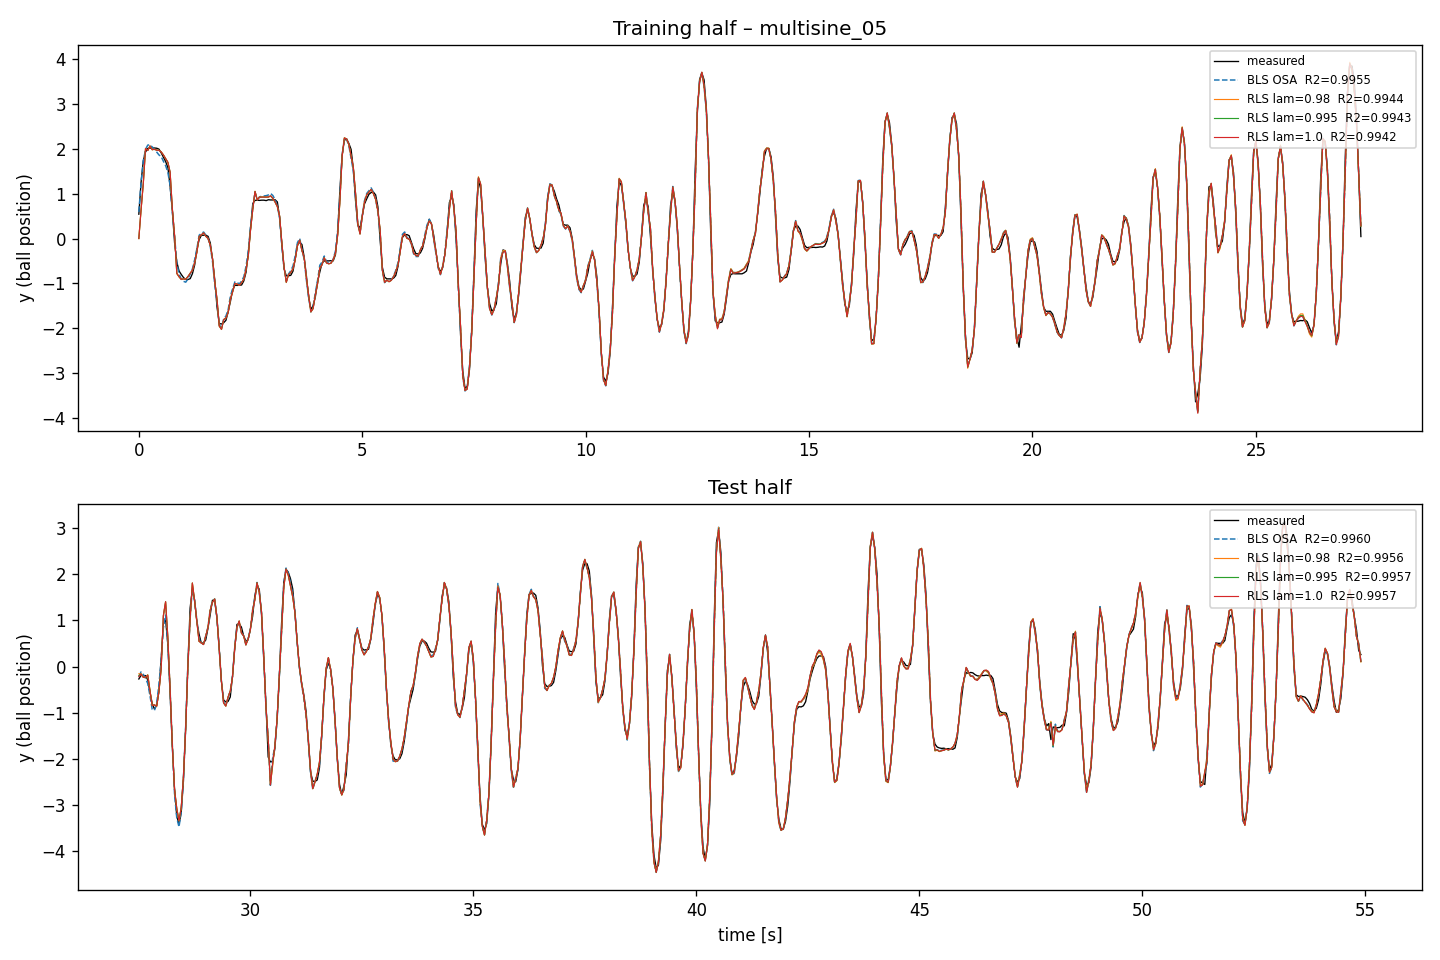

In [3]:
p = max(N_A, N_B)
t_tra = np.arange(Y_tra.size) * ts          # length = u_tra.size - p (OSA/output)
t_tst = (split + np.arange(Y_tst.size)) * ts
t_tra_full = np.arange(u_tra.size) * ts     # length = u_tra.size (parameter history)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
axes[0].plot(t_tra, Y_tra, "k", lw=0.8, label="measured")
axes[0].plot(t_tra, yhat_bls_tra_osa, "--", lw=0.9,
             label=f"BLS OSA  R2={r2_b:.4f}")
for lam, res in rls_results.items():
    axes[0].plot(t_tra, res["yhat_tr_osa"], lw=0.7,
                 label=f"RLS lam={lam}  R2={res['r2_tr']:.4f}")
axes[0].set_title(f"Training half – {EXPERIMENT}")
axes[0].set_ylabel("y (ball position)")
axes[0].legend(fontsize=7, loc="upper right")

axes[1].plot(t_tst, Y_tst, "k", lw=0.8, label="measured")
axes[1].plot(t_tst, yhat_bls_tst_osa, "--", lw=0.9,
             label=f"BLS OSA  R2={r2_bt:.4f}")
for lam, res in rls_results.items():
    axes[1].plot(t_tst, res["yhat_te_osa"], lw=0.7,
                 label=f"RLS lam={lam}  R2={res['r2_te']:.4f}")
axes[1].set_title("Test half")
axes[1].set_xlabel("time [s]")
axes[1].set_ylabel("y (ball position)")
axes[1].legend(fontsize=7, loc="upper right")
fig.tight_layout()
fname = os.path.join(HERE, "bab_rls_time_domain.png")
fig.savefig(fname, dpi=120)
print(f"\nSaved: {fname}")

### Figure 2: parameter evolution (training, best RLS)

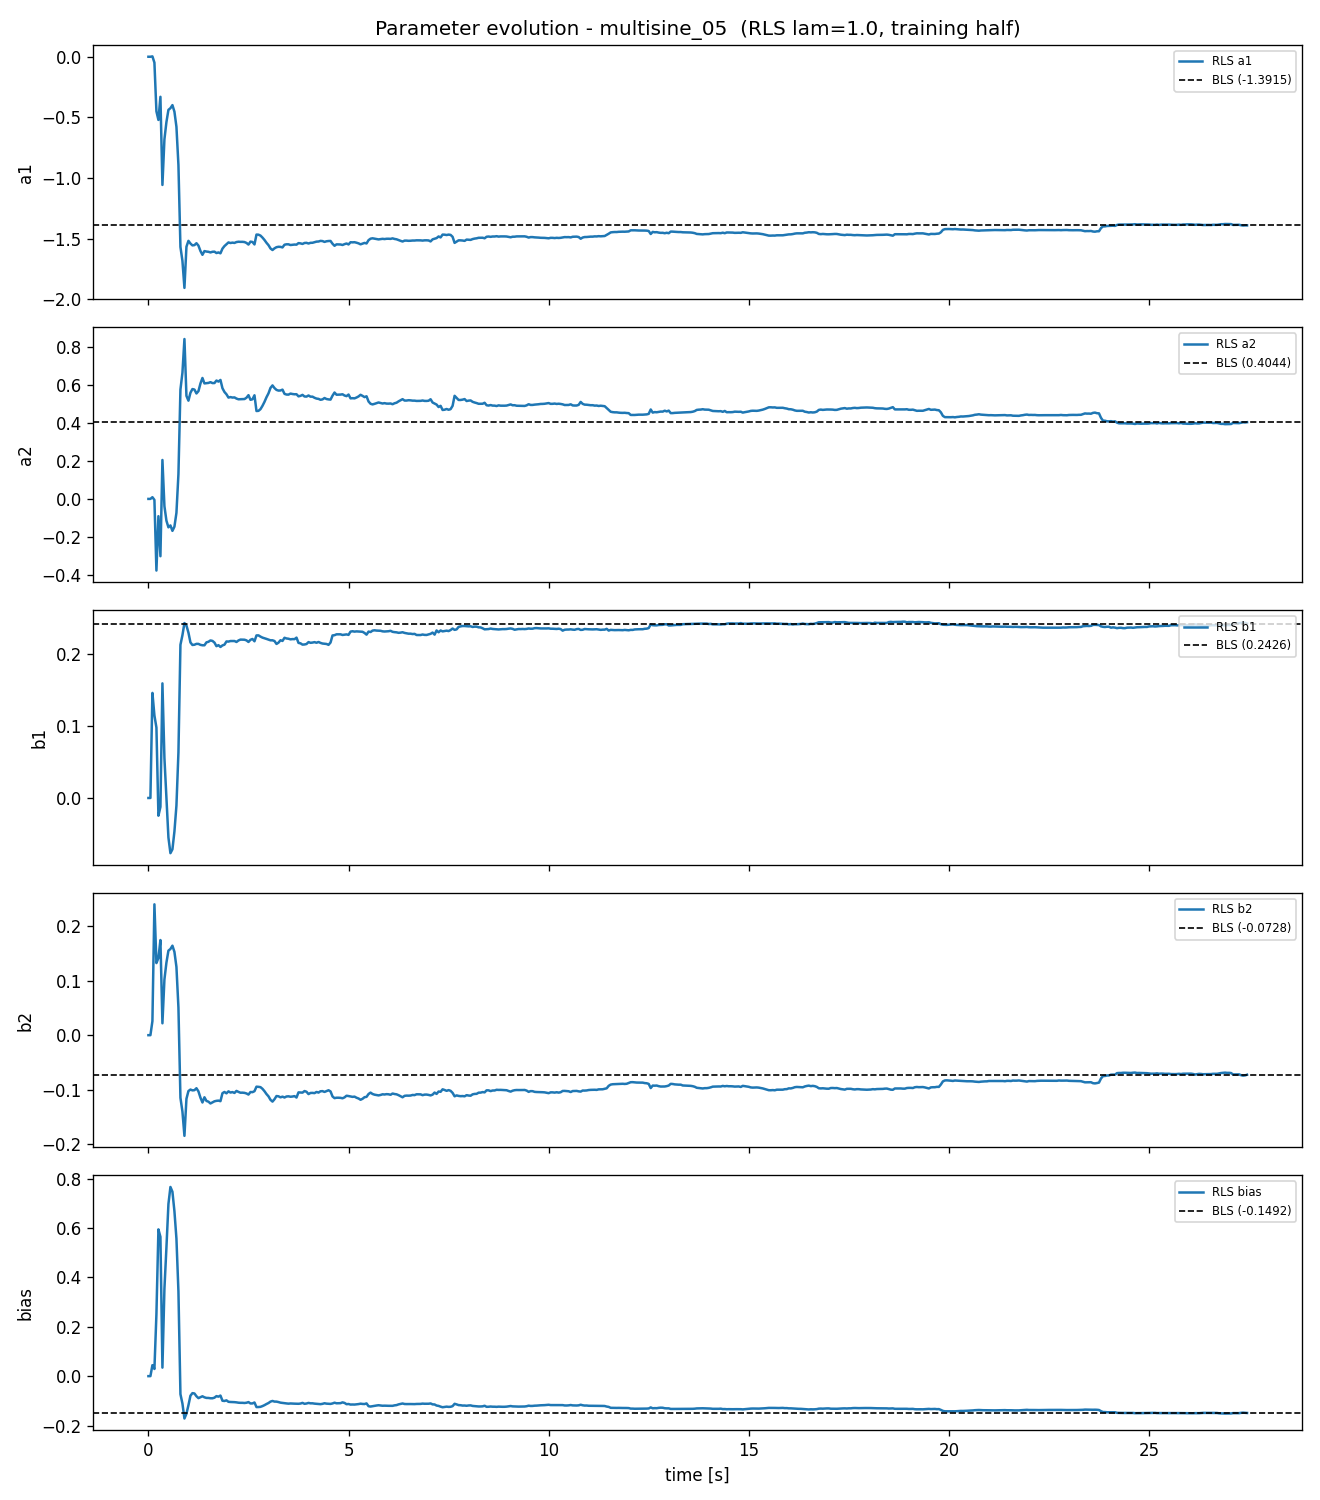

In [1]:
param_labels = ([f"a{i+1}" for i in range(N_A)]
                + [f"b{i+1}" for i in range(N_B)]
                + (["bias"] if BIAS else []))
n_params = len(param_labels)
th_hist_best = rls_results[best_lam]["th_hist_tr"]

fig2, axes2 = plt.subplots(n_params, 1, figsize=(11, 2.5 * n_params),
                           sharex=True)
if n_params == 1:
    axes2 = [axes2]
for j, lbl in enumerate(param_labels):
    axes2[j].plot(t_tra_full, th_hist_best[:, j], label=f"RLS {lbl}")
    axes2[j].axhline(th_bls[j], color="k", ls="--", lw=1,
                     label=f"BLS ({th_bls[j]:.4f})")
    axes2[j].set_ylabel(lbl)
    axes2[j].legend(fontsize=7, loc="upper right")
axes2[0].set_title(
    f"Parameter evolution - {EXPERIMENT}  (RLS lam={best_lam}, training half)"
)
axes2[-1].set_xlabel("time [s]")
fig2.tight_layout()
fname2 = os.path.join(HERE, "bab_rls_param_evolution.png")
fig2.savefig(fname2, dpi=120)
print(f"Saved: {fname2}")

### Figure 3: amplitude spectrum (test half, best RLS vs BLS)

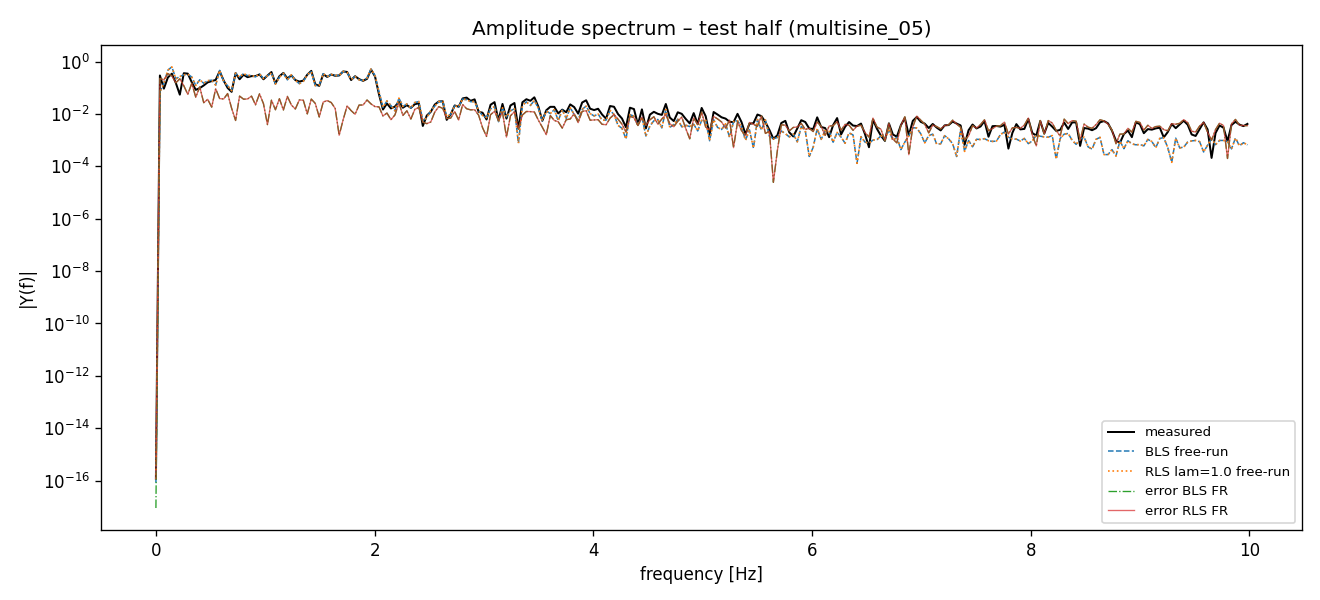

In [2]:
f, m_meas = amplitude_spectrum(Y_tst, ts)
_, m_bls_osa = amplitude_spectrum(yhat_bls_tst_osa, ts)
_, m_bls_fr = amplitude_spectrum(yhat_bls_tst_fr, ts)
_, m_rls_osa = amplitude_spectrum(rls_results[best_lam]["yhat_te_osa"], ts)
_, m_rls_fr = amplitude_spectrum(yhat_rls_tst_fr, ts)
_, m_err_bls = amplitude_spectrum(Y_tst - yhat_bls_tst_fr, ts)
_, m_err_rls = amplitude_spectrum(Y_tst - yhat_rls_tst_fr, ts)

fig3, ax3 = plt.subplots(figsize=(11, 5))
ax3.semilogy(f, m_meas, "k", lw=1.2, label="measured")
ax3.semilogy(f, m_bls_fr, "--", lw=0.9, label="BLS free-run")
ax3.semilogy(f, m_rls_fr, ":", lw=1.0,
             label=f"RLS lam={best_lam} free-run")
ax3.semilogy(f, m_err_bls, "-.", lw=0.8, label="error BLS FR")
ax3.semilogy(f, m_err_rls, lw=0.8, alpha=0.7, label="error RLS FR")
ax3.set_title(f"Amplitude spectrum – test half ({EXPERIMENT})")
ax3.set_xlabel("frequency [Hz]")
ax3.set_ylabel("|Y(f)|")
ax3.legend(fontsize=8)
fig3.tight_layout()
fname3 = os.path.join(HERE, "bab_rls_spectra.png")
fig3.savefig(fname3, dpi=120)
print(f"Saved: {fname3}")